In [114]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ruchikakumbhar/placement-prediction-dataset",
  "placementdata.csv",
)

print("First 5 records:", df.head())



First 5 records:    StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79       NotPlaced  
1               Yes        

In [115]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings

In [116]:
warnings.filterwarnings(action='ignore')

In [117]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [118]:
df.shape

(10000, 12)

In [119]:
df.drop('StudentID',axis=1,inplace=True)

In [120]:
df[df.duplicated()]

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
595,8.5,2,3,2,90,4.8,Yes,Yes,80,84,Placed
1060,8.7,2,3,2,90,4.8,Yes,Yes,79,85,Placed
1887,8.1,2,3,2,90,4.8,Yes,Yes,84,86,Placed
1953,8.5,2,3,2,90,4.8,Yes,Yes,81,85,Placed
2743,8.3,2,3,2,90,4.8,Yes,Yes,80,88,Placed
...,...,...,...,...,...,...,...,...,...,...,...
9820,8.2,1,3,2,90,4.8,Yes,Yes,81,83,Placed
9902,8.3,2,3,2,90,4.8,Yes,Yes,80,84,Placed
9953,8.4,2,3,2,90,4.8,Yes,Yes,79,85,Placed
9977,8.3,2,3,2,90,4.8,Yes,Yes,82,88,Placed


In [121]:
df=df.drop_duplicates()

In [122]:
df.dtypes

CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus               object
dtype: object

In [123]:
df.isnull().sum()

CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [124]:
df.describe()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000
mean,7.693946,1.042808,2.019944,1.006849,79.376209,4.320679,69.093372,74.425766
std,0.639961,0.663699,0.867118,0.903612,8.140884,0.411211,10.428709,8.901786
min,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [125]:
from sklearn.model_selection import train_test_split
train_ds,test_ds=train_test_split(df,test_size=0.25,shuffle=True,random_state=404)

In [126]:
train_ds

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
7866,6.8,1,1,0,71,4.4,No,No,60,68,NotPlaced
1671,8.4,1,2,0,80,3.3,No,No,55,63,NotPlaced
8895,7.6,1,1,0,74,4.3,No,No,58,71,NotPlaced
9639,8.7,2,3,2,90,4.8,Yes,Yes,81,86,Placed
9215,7.6,0,1,0,78,4.3,Yes,Yes,76,77,Placed
...,...,...,...,...,...,...,...,...,...,...,...
6057,7.5,1,3,0,71,4.2,No,Yes,65,67,NotPlaced
5126,8.0,1,1,0,69,3.6,No,No,55,62,NotPlaced
5323,8.7,1,3,3,89,4.8,Yes,Yes,74,83,NotPlaced
5909,7.5,0,2,1,80,4.7,No,Yes,82,82,Placed


<!-- ## Univariate Analysis -->

In [127]:
categorical_cols=['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus','Workshops/Certifications','Projects','Internships']
numerical_cols=['CGPA','AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks']

CGPA


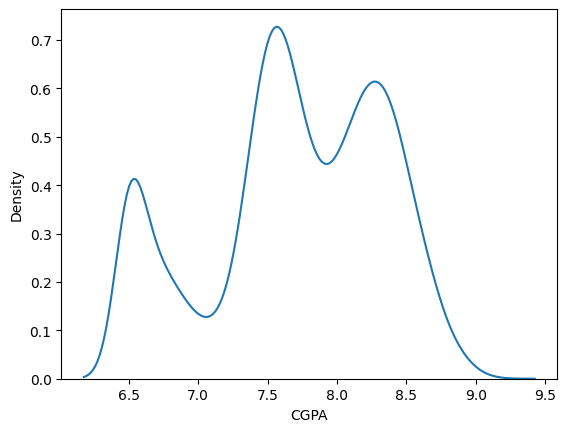

AptitudeTestScore


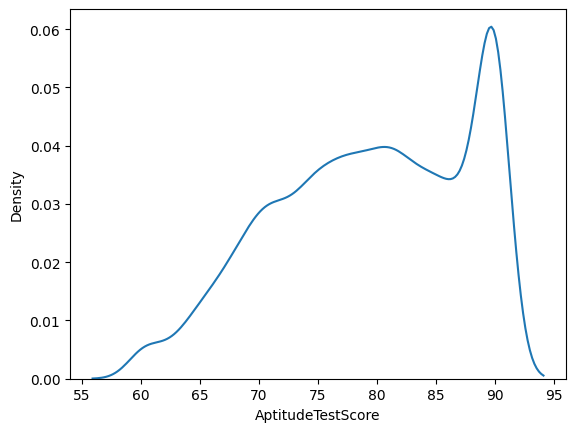

SoftSkillsRating


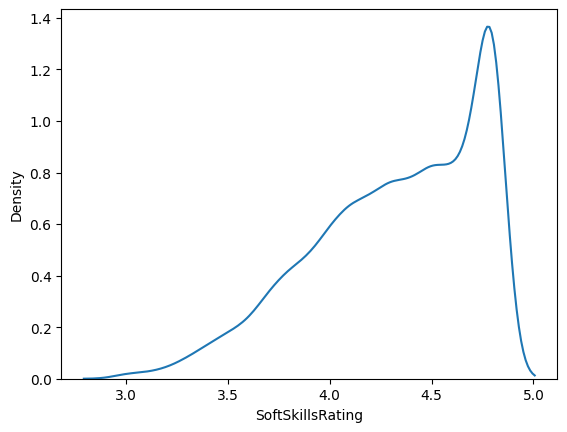

SSC_Marks


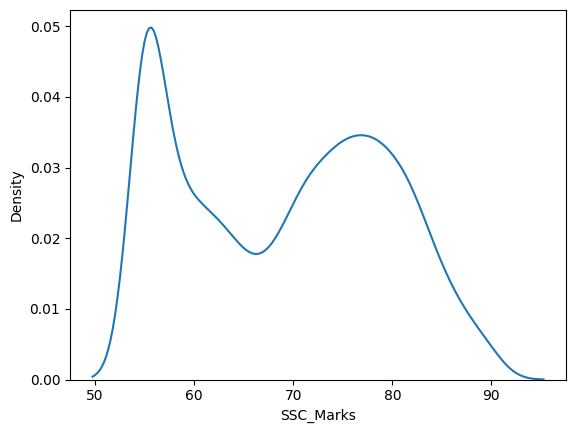

HSC_Marks


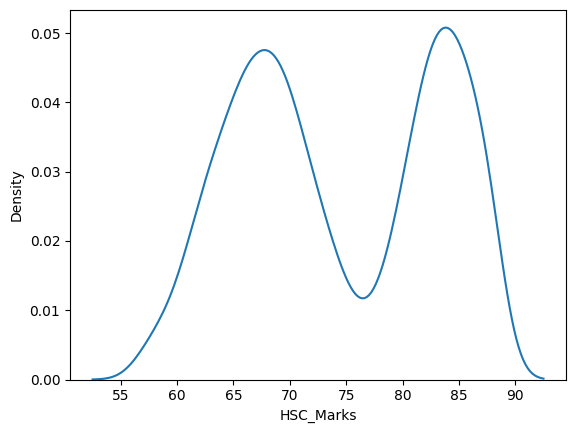

In [128]:
## Checking Distribution of Numerical Data
for col in numerical_cols:
    print(col)
    sns.kdeplot(train_ds[col])
    plt.show()

In [129]:
df.head(1)

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced


CGPA


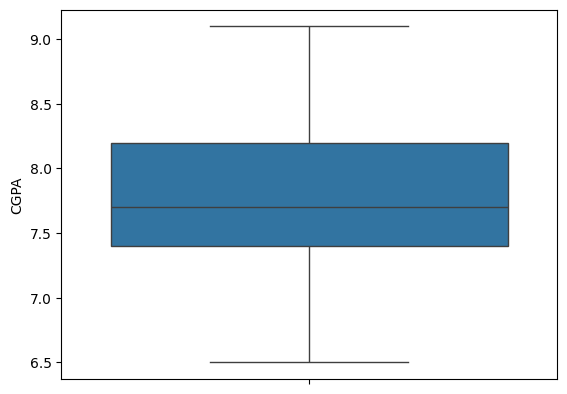

AptitudeTestScore


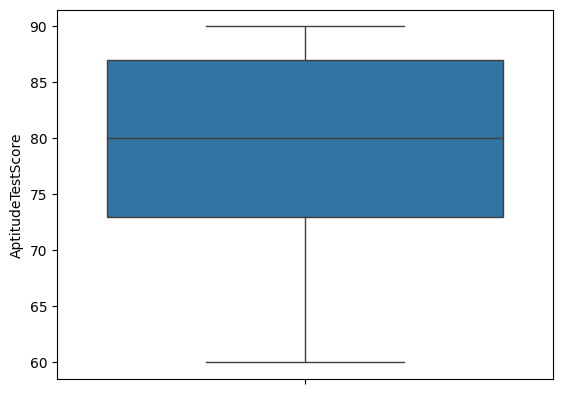

SoftSkillsRating


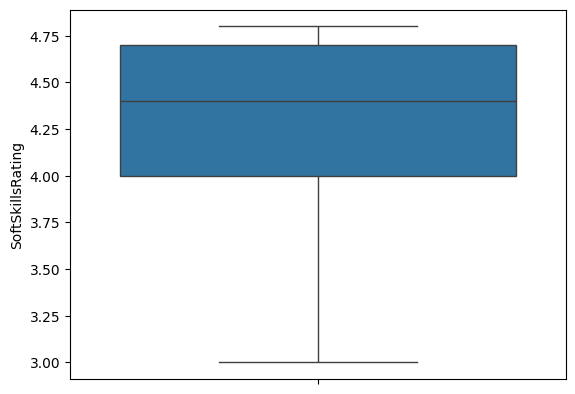

SSC_Marks


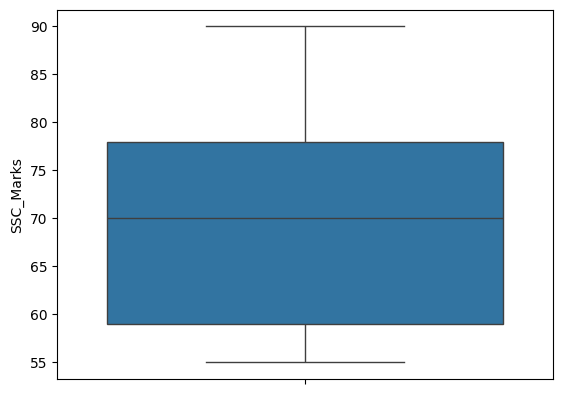

HSC_Marks


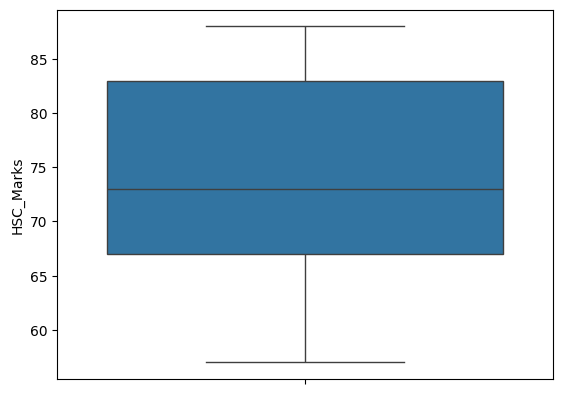

In [130]:
## Checking Distribution of Numerical Data
for col in numerical_cols:
    print(col)
    sns.boxplot(train_ds[col])
    # plt.plot()
    plt.show()

<!-- ## Conclusion:
### Analysis On Each Column:
 CPGA: Most students have CGPA between 7.1 and 7.6, 
 and the second largest group of students has CGPA between 8.1 and 8.5,
 very less people have very high CGPA

 AptitudeTest Score: Most students have apptitude test score  between 87 and 92, 
 and the second largest group of students has between 70 and 85, 
 very less people have very low Aptitude Score.


 SoftSkill Score: Most students have Softskill Skill rating lies between 4.6 and 4.9, 
 and the second largest group of students rating lies between 4 and 4.5 
 very less people have very low SoftSkill Score.



  SSC_MARKS: Most students SSC_MARKS lies between 50 and 55, 
  and the second largest group of students marks lies between 70 and 80 
  very less people have very highest and less then 50 Score.


  SSC_MARKS: Most students SSC_MARKS lies between 80 and 85, 
  and the second largest group of students marks lies between 60 and 70 
  very less people have very highest and less then 60 Score.

### Conclusion Of Analysis:
  According these numbers and my analysis, i came to the result that our data is collected from high performing and average students,

### Current Condition and Action Required:
 ApptitudeTestScore and SoftSkill Rating Cols: they are left skewed so if we use Linear Model we should required to Apply the Function Transformer  with x^2 func.
 SSC_Marks Col: it is left skewed so if we use Linear Model we should required to Apply the Function Transformer with log1p func. -->

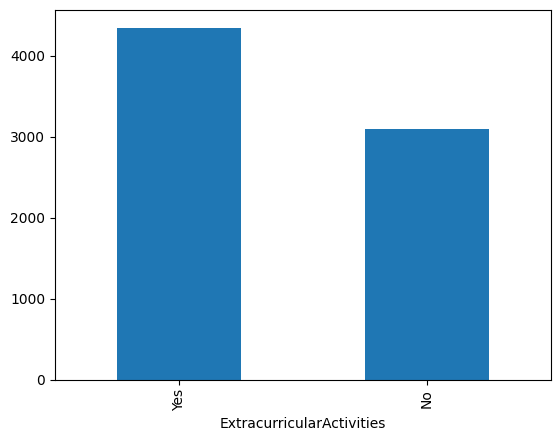

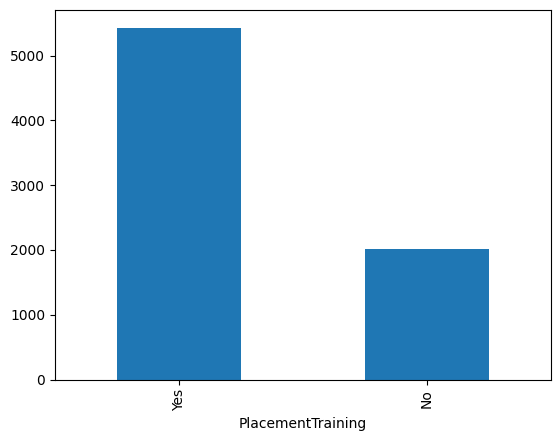

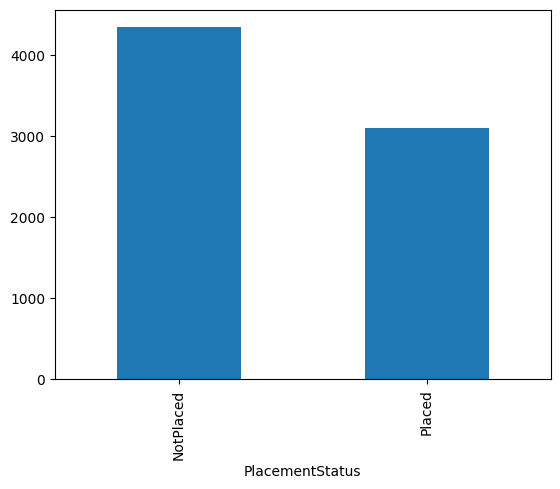

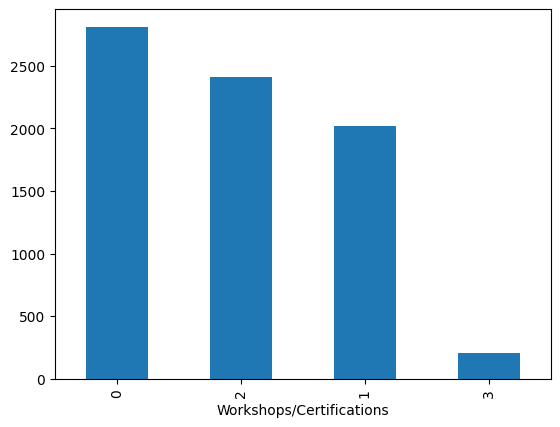

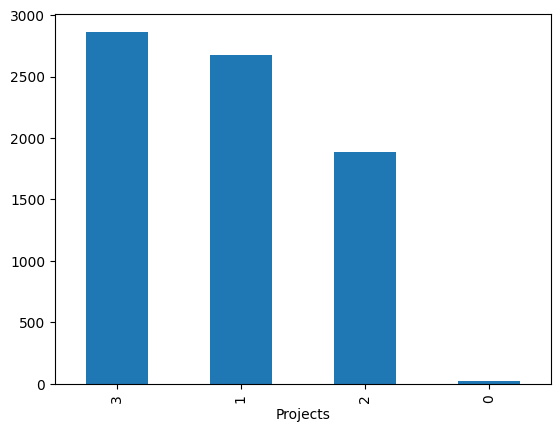

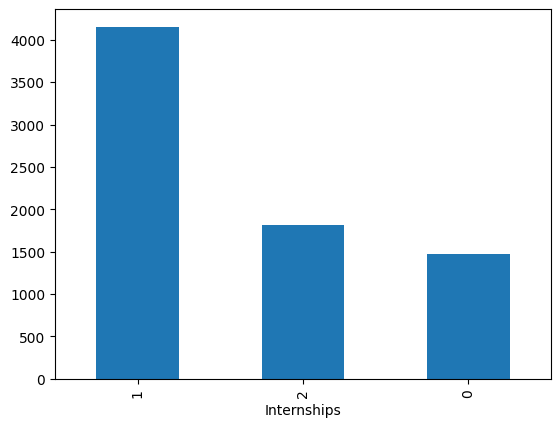

In [131]:
for col in categorical_cols:
    train_ds[col].value_counts().plot(kind='bar')
    plt.show()

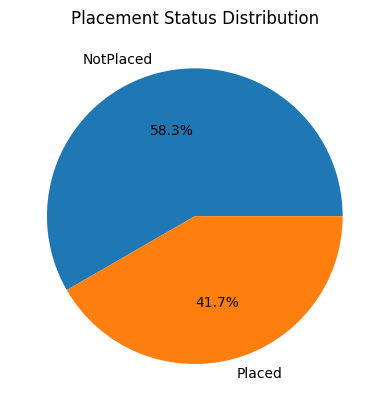

In [132]:
plt.pie(
    train_ds['PlacementStatus'].value_counts(),
    labels=df['PlacementStatus'].value_counts().index,
    autopct='%1.1f%%'
)
plt.title('Placement Status Distribution')
plt.show()

<!-- ### Analysis on Each Column:
Projects: most of the people in our dataset has builded the projects, and very few persons have very less projects
Certificate: most of the people in our dataset has 1 or 2 certificate or workshop, very less person has more then 2 certificates
placement training: most of the people in our dataset take the placement training,


Current Condition and Action Required:
Placement Status, Placement Training,and Extracurricular Activity Columns required OneHotEncoding -->

<!-- ## Multivariate Analysis -->

In [133]:
categorical_cols

['ExtracurricularActivities',
 'PlacementTraining',
 'PlacementStatus',
 'Workshops/Certifications',
 'Projects',
 'Internships']

<Axes: xlabel='CGPA', ylabel='Density'>

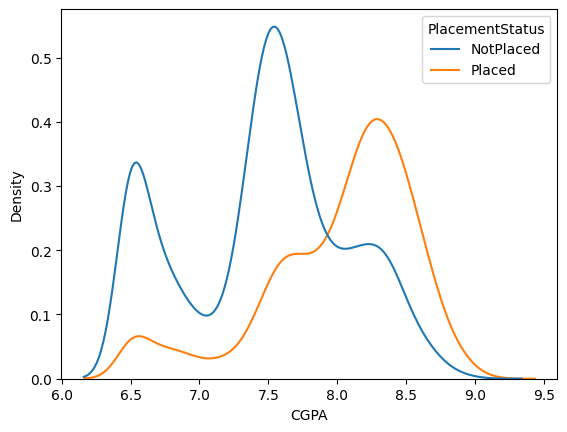

In [134]:
sns.kdeplot(x='CGPA',hue='PlacementStatus',data=train_ds)

<!-- ### Conclusion:
According to this Analysis if a person have a CGPA has Higher CGPA, They have higher chance that they should placed, mostly if CGPA greater then 7.5 -->

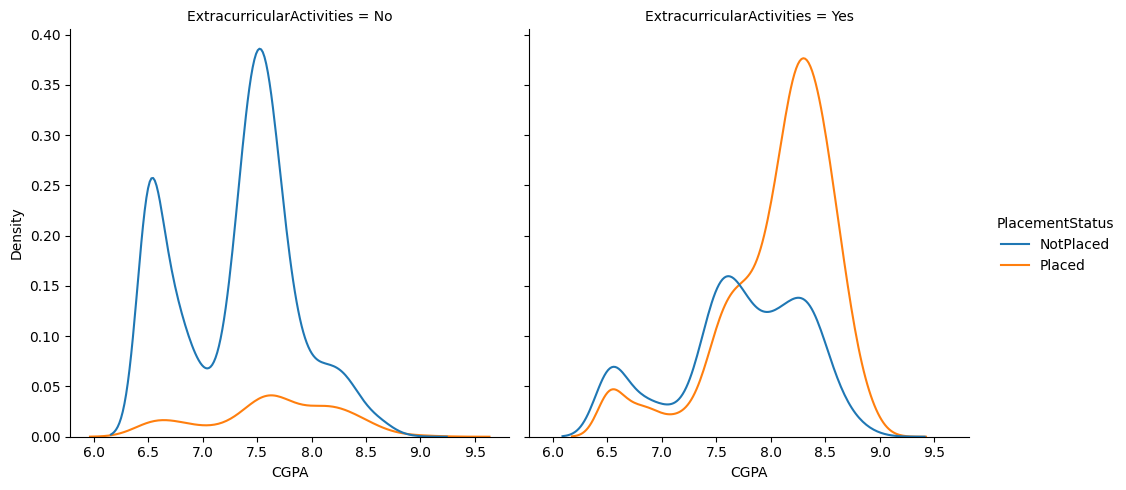

In [135]:
sns.displot(data=train_ds, x='CGPA', hue='PlacementStatus', col='ExtracurricularActivities' ,kind='kde')

<!-- ### Conclusion:
According to this Analysis if a person has higher CGPA and also they are included in Extracurriculum Activities, they have higher chance that they should placed. -->

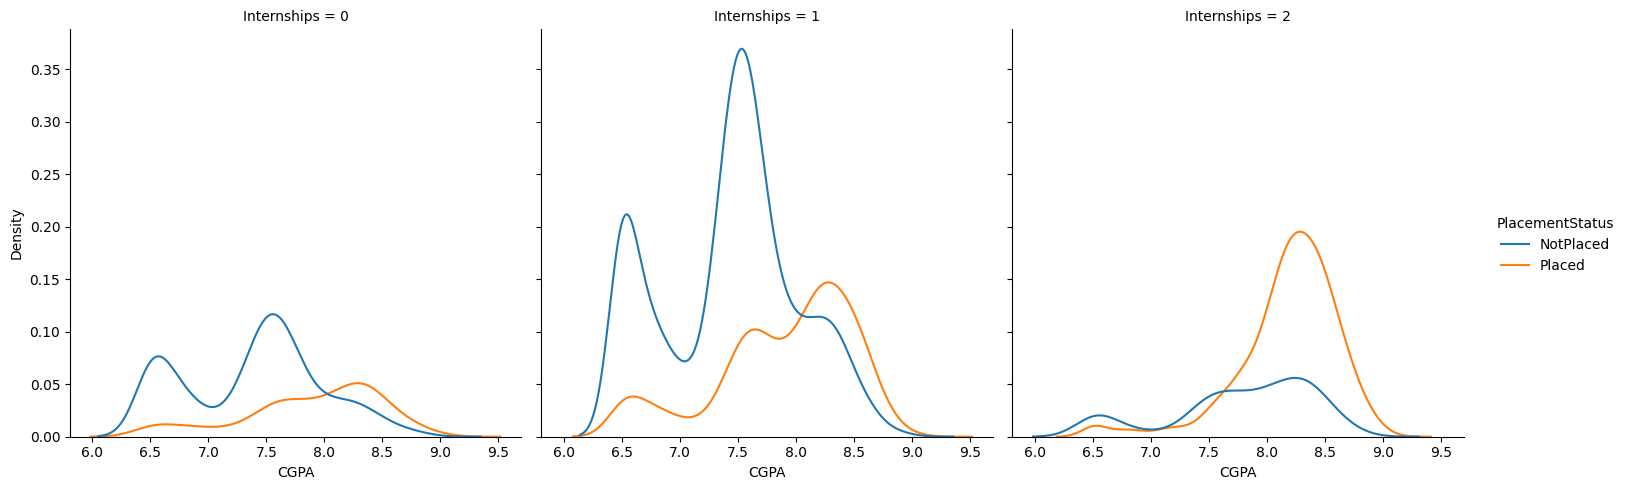

In [136]:
sns.displot(data=train_ds, x='CGPA', hue='PlacementStatus', col='Internships' ,kind='kde')

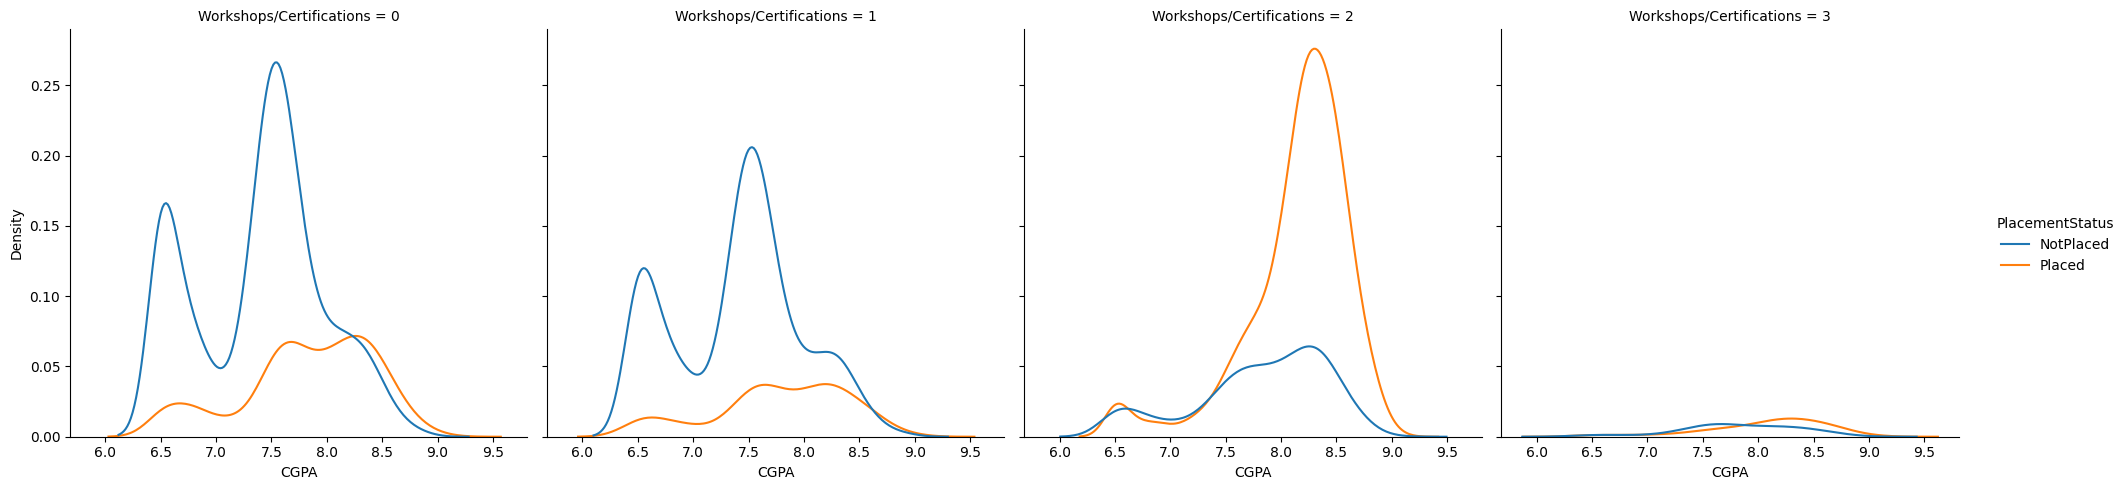

In [137]:
sns.displot(data=train_ds, x='CGPA', hue='PlacementStatus', col='Workshops/Certifications' ,kind='kde')

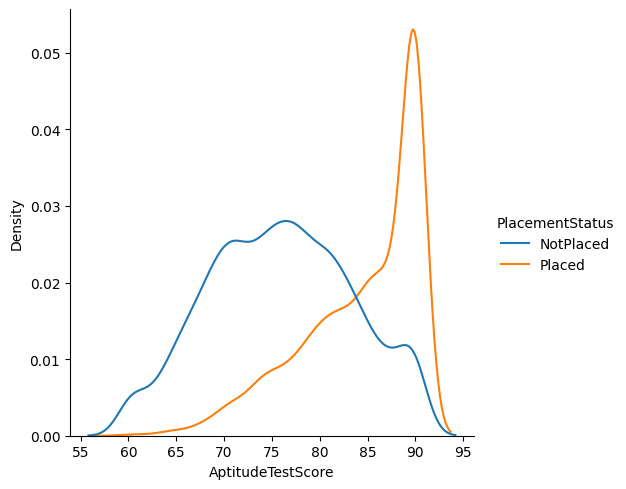

In [138]:
sns.displot(data=train_ds, x='AptitudeTestScore', hue='PlacementStatus',kind='kde')

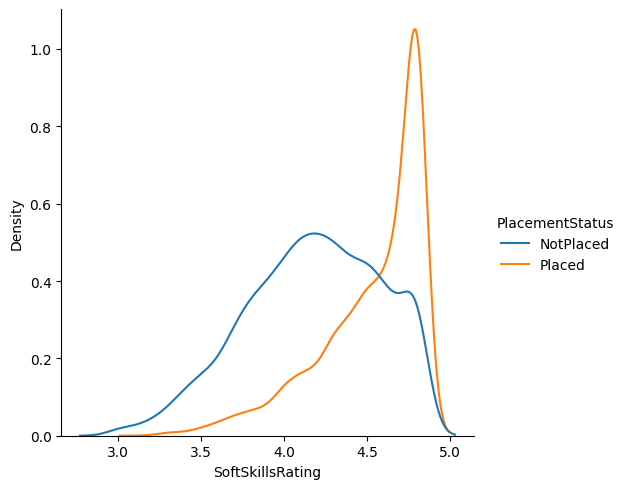

In [139]:
sns.displot(data=train_ds, x='SoftSkillsRating', hue='PlacementStatus',kind='kde')

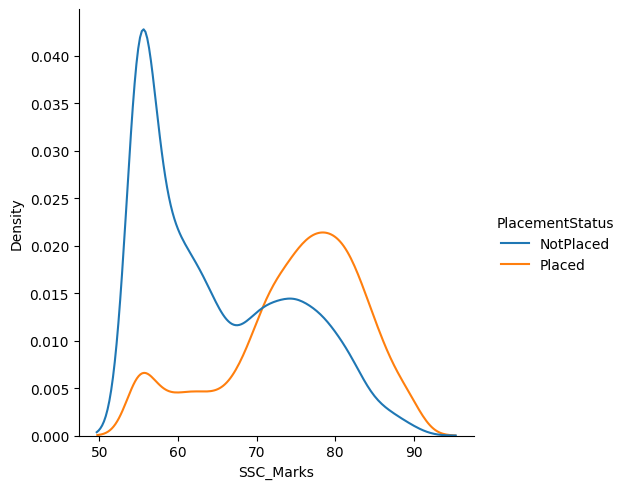

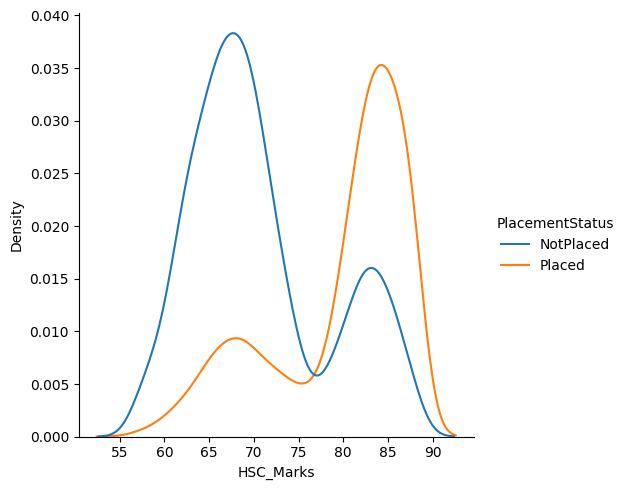

In [140]:
sns.displot(data=train_ds, x='SSC_Marks', hue='PlacementStatus',kind='kde')
sns.displot(data=train_ds, x='HSC_Marks', hue='PlacementStatus',kind='kde')	

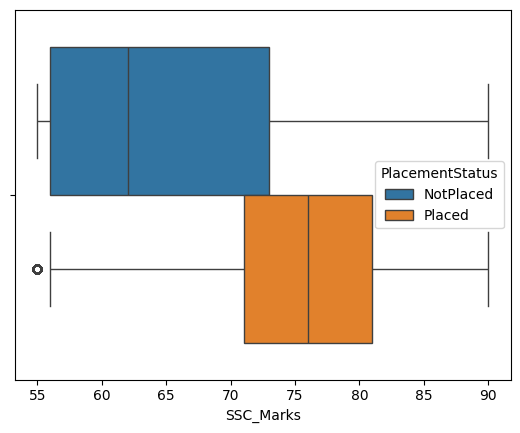

<Axes: xlabel='HSC_Marks'>

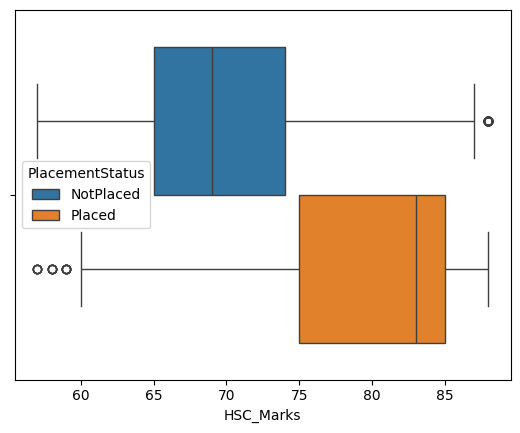

In [141]:
sns.boxplot(data=train_ds, x='SSC_Marks', hue='PlacementStatus')
plt.show()
sns.boxplot(data=train_ds, x='HSC_Marks', hue='PlacementStatus')	

<!-- ###  Let's Checking On Basis of PlacementTraining -->

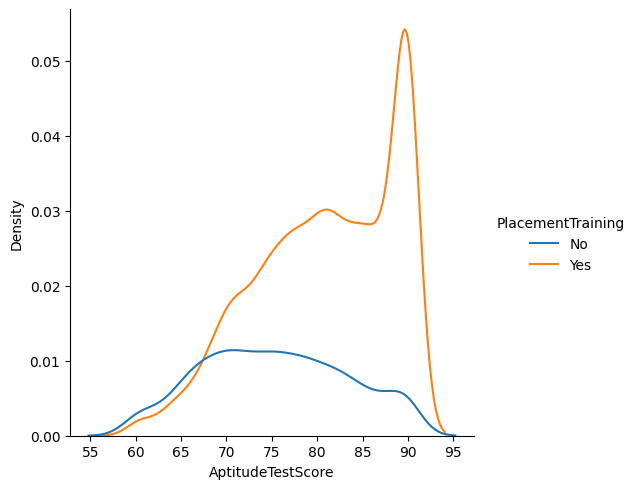

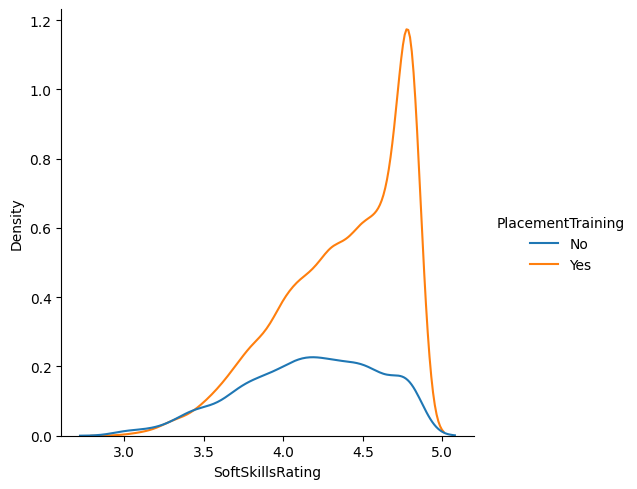

In [142]:
sns.displot(data=train_ds, x='AptitudeTestScore', hue='PlacementTraining',kind='kde')
sns.displot(data=train_ds, x='SoftSkillsRating', hue='PlacementTraining',kind='kde')	

[]

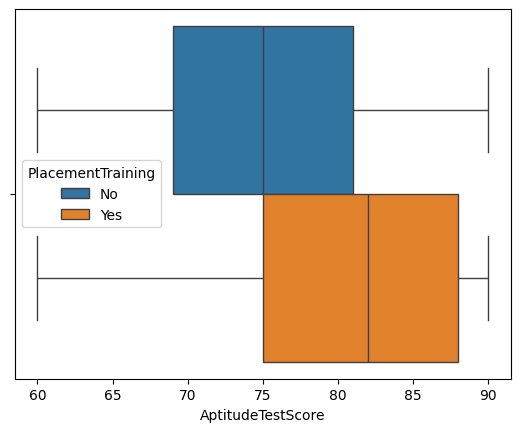

In [143]:
sns.boxplot(data=train_ds, x='AptitudeTestScore', hue='PlacementTraining')
plt.plot()

<Axes: xlabel='SoftSkillsRating'>

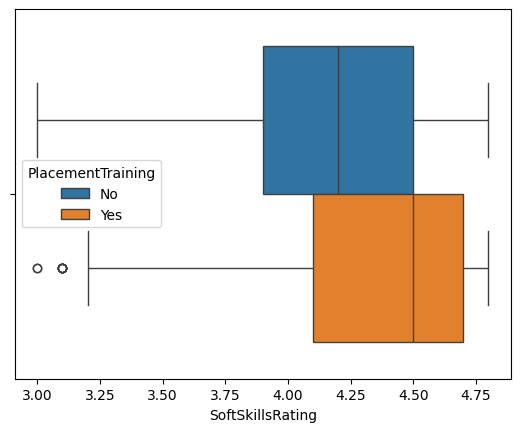

In [144]:
sns.boxplot(data=train_ds, x='SoftSkillsRating', hue='PlacementTraining')	


In [145]:
# outlier col=softskillsRating handling on basis of placementTranining
# outlier col=HSC_Marks and SSC_Marks handling on basis of placementStatus

In [146]:
train_ds.head(1)

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
7866,6.8,1,1,0,71,4.4,No,No,60,68,NotPlaced


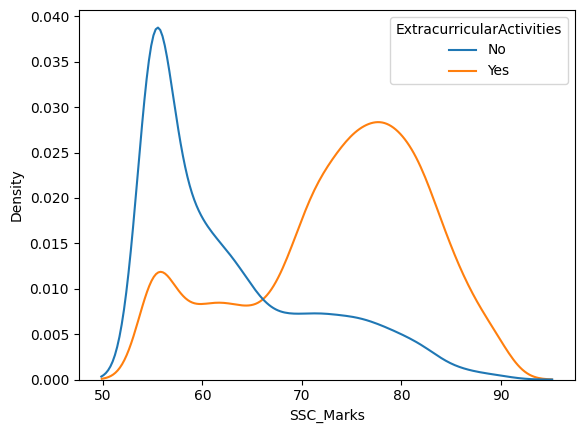

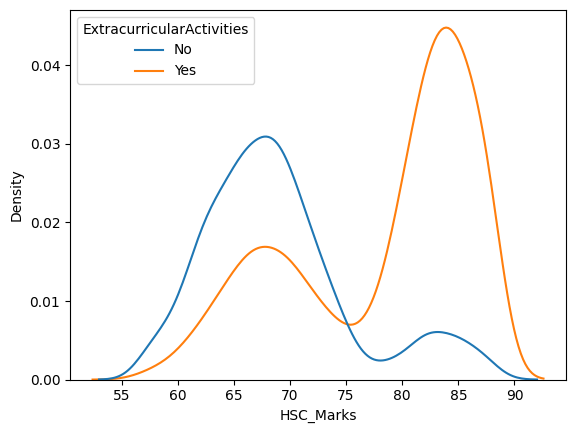

In [147]:
sns.kdeplot(data=train_ds, x='SSC_Marks', hue='ExtracurricularActivities')
plt.show()
sns.kdeplot(data=train_ds, x='HSC_Marks', hue='ExtracurricularActivities')
plt.show()

<!-- ####  Encoding the Target Column -->

In [148]:
from sklearn.preprocessing import LabelEncoder

In [149]:
lbl=LabelEncoder()
lbl.fit(train_ds['PlacementStatus'])

LabelEncoder()

In [150]:
train_ds['PlacementStatus']=lbl.transform(train_ds['PlacementStatus'])
test_ds['PlacementStatus']=lbl.transform(test_ds['PlacementStatus'])

In [151]:
train_ds['PlacementStatus']

7866    0
1671    0
8895    0
9639    1
9215    1
       ..
6057    0
5126    0
5323    0
5909    1
7950    1
Name: PlacementStatus, Length: 7446, dtype: int64

In [152]:
train_ds.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
7866,6.8,1,1,0,71,4.4,No,No,60,68,0
1671,8.4,1,2,0,80,3.3,No,No,55,63,0
8895,7.6,1,1,0,74,4.3,No,No,58,71,0
9639,8.7,2,3,2,90,4.8,Yes,Yes,81,86,1
9215,7.6,0,1,0,78,4.3,Yes,Yes,76,77,1


<Axes: >

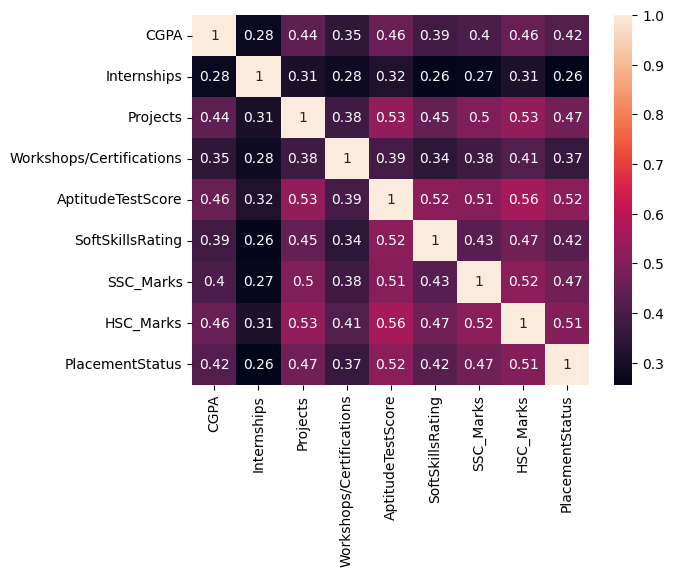

In [153]:
sns.heatmap(train_ds.drop(columns=['ExtracurricularActivities','PlacementTraining']).corr(),annot=True)

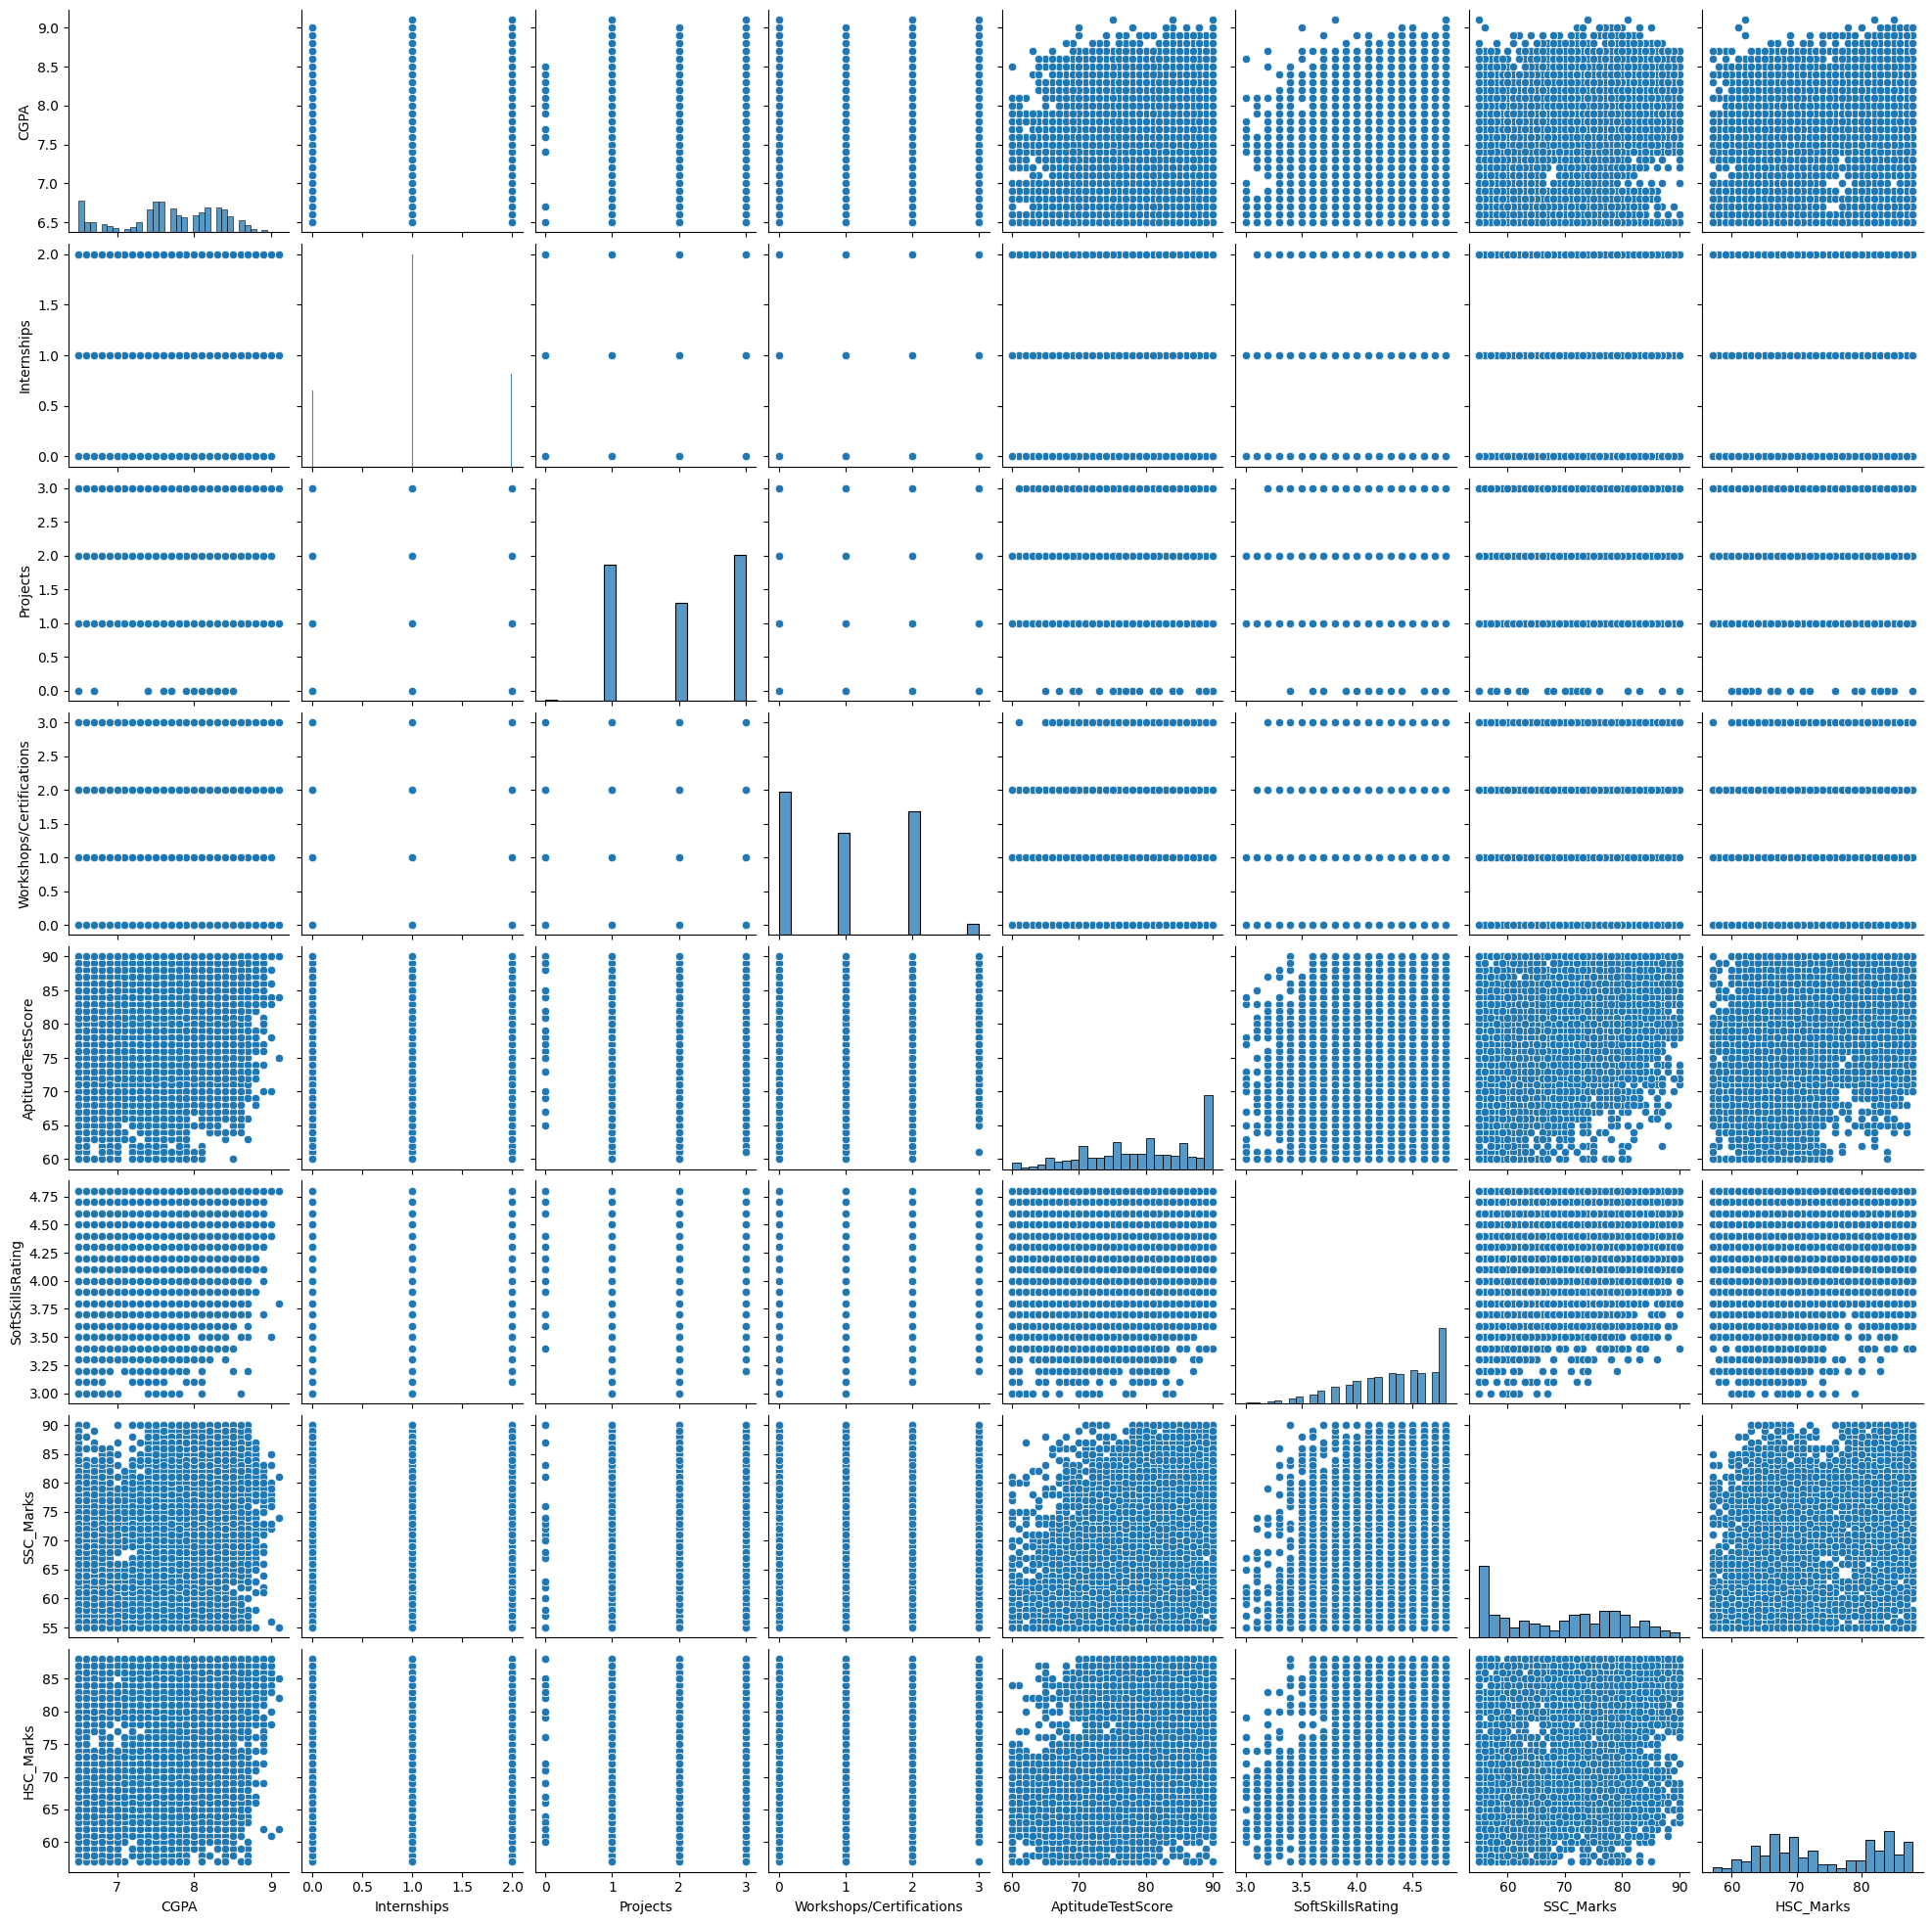

In [156]:
sns.pairplot(df)

<!-- ### Handling Outlier -->

#### Let Handling Outliers

In [ ]:
# outlier col=softskillsRating handling on basis of placementTranining
# outlier col=HSC_Marks and SSC_Marks handling on basis of placementStatus

In [157]:
train_ds.head(1)

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
7866,6.8,1,1,0,71,4.4,No,No,60,68,0


In [158]:
def iqr_cap(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return series.clip(lower, upper)

In [159]:
train_ds['SoftSkillsRating']=train_ds.groupby('PlacementTraining', group_keys=False)['SoftSkillsRating'].transform(iqr_cap)

In [160]:
train_ds['SSC_Marks']=train_ds.groupby('PlacementStatus', group_keys=False)['SSC_Marks'].transform(iqr_cap)

In [161]:
train_ds['HSC_Marks']=train_ds.groupby('PlacementStatus', group_keys=False)['HSC_Marks'].transform(iqr_cap)

<Axes: xlabel='SoftSkillsRating'>

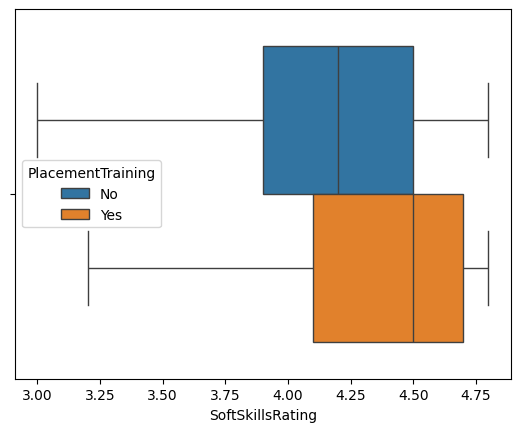

In [162]:
sns.boxplot(data=train_ds, x='SoftSkillsRating', hue='PlacementTraining')	

In [163]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,PowerTransformer


In [164]:
x_train=train_ds.drop('PlacementStatus',axis=1)
x_test=test_ds.drop('PlacementStatus',axis=1)
y_train=train_ds['PlacementStatus']
y_test=test_ds['PlacementStatus']

In [165]:
train_ds.isnull().sum()

CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [166]:
x_train.shape

(7446, 10)

In [167]:
x_test.shape

(2482, 10)

In [168]:
x_train.head(1)

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
7866,6.8,1,1,0,71,4.4,No,No,60,68.0


In [169]:
y_train

7866    0
1671    0
8895    0
9639    1
9215    1
       ..
6057    0
5126    0
5323    0
5909    1
7950    1
Name: PlacementStatus, Length: 7446, dtype: int64

In [172]:
x_train.head(1)

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
7866,6.8,1,1,0,71,4.4,No,No,60,68.0


### Started Feature Engineering

In [171]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,StackingClassifier
from xgboost import XGBClassifier
import mlflow
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [58]:
x_train['HasExperience'] = (x_train['Internships'] > 0).astype(int)
x_test['HasExperience'] = (x_test['Internships'] > 0).astype(int)

In [59]:
x_train['AcademicScore'] = (x_train['SSC_Marks'] + x_train['HSC_Marks'] + x_train['CGPA']) / 3
x_test['AcademicScore'] = (x_test['SSC_Marks'] + x_test['HSC_Marks'] + x_test['CGPA']) / 3

In [60]:
# Practical exposure
x_train['ExperienceScore'] = x_train['Projects'] + x_train['Workshops/Certifications']
x_test['ExperienceScore'] = x_test['Projects'] + x_test['Workshops/Certifications']

In [173]:
x_train['ExtracurricularActivities'] = x_train['ExtracurricularActivities'].map({'No': 0, 'Yes': 1})
x_train['PlacementTraining'] = x_train['PlacementTraining'].map({'No': 0, 'Yes': 1})
x_test['ExtracurricularActivities'] = x_test['ExtracurricularActivities'].map({'No': 0, 'Yes': 1})
x_test['PlacementTraining'] = x_test['PlacementTraining'].map({'No': 0, 'Yes': 1})

In [62]:
x_train['OverallScore'] = x_train['AcademicScore'] + x_train['ExperienceScore']
x_test['OverallScore'] = x_test['AcademicScore'] + x_test['ExperienceScore']

In [174]:
x_train.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
7866,6.8,1,1,0,71,4.4,0,0,60,68.0
1671,8.4,1,2,0,80,3.3,0,0,55,63.0
8895,7.6,1,1,0,74,4.3,0,0,58,71.0
9639,8.7,2,3,2,90,4.8,1,1,81,86.0
9215,7.6,0,1,0,78,4.3,1,1,76,77.0


#### Running Single Model to Find Important Features

In [186]:
rf=RandomForestClassifier(max_depth=5)

In [187]:
rf.fit(x_train,y_train)
y_train_pred=rf.predict(x_train)
y_test_pred=rf.predict(x_test)

print("train accuracy",accuracy_score(y_train,y_train_pred))
print("train recall",recall_score(y_train,y_train_pred))
print("train precision",precision_score(y_train,y_train_pred))
print("train f1",f1_score(y_train,y_train_pred))


print("test accuracy",accuracy_score(y_test,y_test_pred))
print("test recall",recall_score(y_test,y_test_pred))
print("test precision",precision_score(y_test,y_test_pred))
print("test f1",f1_score(y_test,y_test_pred))   

train accuracy 0.8080848777867311
train recall 0.7541089268449888
train precision 0.7784431137724551
train f1 0.7660828286135211
test accuracy 0.7941176470588235
test recall 0.73046875
test precision 0.7609359104781281
test f1 0.7453911310413552


In [188]:
for i in range(len(rf.feature_importances_)):
    print(x_train.columns[i],'  ===>>  ',rf.feature_importances_[i]*100)

CGPA   ===>>   3.588317151916381
Internships   ===>>   0.1853913959217414
Projects   ===>>   15.281670959452962
Workshops/Certifications   ===>>   6.620414613887597
AptitudeTestScore   ===>>   17.545822348439085
SoftSkillsRating   ===>>   3.147816197565821
ExtracurricularActivities   ===>>   20.798026435942134
PlacementTraining   ===>>   2.269855907129926
SSC_Marks   ===>>   10.03736818855376
HSC_Marks   ===>>   20.52531680119058


In [ ]:
# # Columns For Deleting
# del_cols=["Internships",
# "HasExperience",
# "SoftSkillsRating",
# "PlacementTraining",
# "CGPA",
# "Workshops/Certifications"]

In [178]:
# x_train=x_train.drop(columns=del_cols)
# x_test=x_test.drop(columns=del_cols)

In [189]:
x_train

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
7866,6.8,1,1,0,71,4.4,0,0,60,68.0
1671,8.4,1,2,0,80,3.3,0,0,55,63.0
8895,7.6,1,1,0,74,4.3,0,0,58,71.0
9639,8.7,2,3,2,90,4.8,1,1,81,86.0
9215,7.6,0,1,0,78,4.3,1,1,76,77.0
...,...,...,...,...,...,...,...,...,...,...
6057,7.5,1,3,0,71,4.2,0,1,65,67.0
5126,8.0,1,1,0,69,3.6,0,0,55,62.0
5323,8.7,1,3,3,89,4.8,1,1,74,83.0
5909,7.5,0,2,1,80,4.7,0,1,82,82.0


##### Applying Top Models And Applying Hyperparameter Tunning on it 

In [190]:
import dagshub
dagshub.init(repo_owner='umiii-786', repo_name='placement-prediction-Model', mlflow=True)

Initialized MLflow to track repo "umiii-786/placement-prediction-Model"

Repository umiii-786/placement-prediction-Model initialized!

In [191]:
mlflow.set_tracking_uri("https://dagshub.com/umiii-786/placement-prediction-Model.mlflow")

In [193]:
models = {
        "lg_model":LogisticRegression(),
        'svc':SVC(),
        "rf_model":RandomForestClassifier(max_depth=5),
        "gb":GradientBoostingClassifier(max_depth=5),
        "xgb": XGBClassifier(max_depth=5),
        "lgb":LGBMClassifier(max_depth=5),
        "catgb":CatBoostClassifier(max_depth=5),
}

In [194]:
mlflow.set_experiment(experiment_name='Baseline-Models-of-Placement-Prediction')
with mlflow.start_run(run_name="With Original Features") as parent:
    for name,model in models.items():
        with mlflow.start_run(run_name=name,nested=bool) as child:
            print('running ',name,' model and tracking their matrix ')
                        
            model.fit(x_train,y_train)
            y_train_pred=model.predict(x_train)
            y_test_pred=model.predict(x_test)

            mlflow.log_metric("train accuracy",accuracy_score(y_train,y_train_pred))
            mlflow.log_metric("train recall",recall_score(y_train,y_train_pred))
            mlflow.log_metric("train precision",precision_score(y_train,y_train_pred))
            mlflow.log_metric("train f1",f1_score(y_train,y_train_pred))
            
            mlflow.log_metric("test accuracy",accuracy_score(y_test,y_test_pred))
            mlflow.log_metric("test recall",recall_score(y_test,y_test_pred))
            mlflow.log_metric("test precision",precision_score(y_test,y_test_pred))
            mlflow.log_metric("test f1",f1_score(y_test,y_test_pred))

            print("test accuracy",accuracy_score(y_test,y_test_pred))
            print("test recall",recall_score(y_test,y_test_pred))
            print("test precision",precision_score(y_test,y_test_pred))
            print("test f1",f1_score(y_test,y_test_pred))         

running  lg_model  model and tracking their matrix 
test accuracy 0.7784045124899275
test recall 0.7470703125
test precision 0.7244318181818182
test f1 0.7355769230769231
🏃 View run lg_model at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/3/runs/3807c8da5b084e29a6f55487076c9227
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/3
running  svc  model and tracking their matrix 
test accuracy 0.7771958098307816
test recall 0.70703125
test precision 0.7410440122824974
test f1 0.7236381809095452
🏃 View run svc at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/3/runs/2315ae66bfdc4021a5f878fa970bcfe2
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/3
running  rf_model  model and tracking their matrix 
test accuracy 0.7925060435132957
test recall 0.7314453125
test precision 0.7573306370070778
test f1 0.7441629408842524
🏃 View run 

In [195]:
from sklearn.model_selection import GridSearchCV

#### these are some Power Full Model that i have got after Apply running Models as a baseline
####### Gradient Boosting
####### Extreme Gradient Boosting
####### Light Gradient Boosting

#### Applying the Gradient Boosting Model and Applying Hyperparameter Tunning on It

In [196]:
gb_param_grid = {
    'n_estimators': [100,150,200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'subsample': [0.5,0.8, 1.0]
}

In [197]:
gb = GradientBoostingClassifier(random_state=42)

In [ ]:
grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=5,
    scoring='f1',   # better than accuracy
    n_jobs=-1
)

In [199]:
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5], 'min_samples_split': [2, 5], 'n_estimators': [100, 150, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [200]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 0.5}
Best Score: 0.7750377580563603


In [201]:
y_test_pred = grid.best_estimator_.predict(x_test)
y_train_pred = grid.best_estimator_.predict(x_train)

# Train Evaluation

# Train Evaluation
print("Accuracy:", accuracy_score(y_train,y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1 Score:", f1_score(y_train, y_train_pred))

# Test Evaluation
print('\n\n test accuracy')
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

Accuracy: 0.8274241203330648
Precision: 0.7986202365308804
Recall: 0.7834353851111827
F1 Score: 0.7909549373678217


 test accuracy
Accuracy: 0.7965350523771152
Precision: 0.764525993883792
Recall: 0.732421875
F1 Score: 0.7481296758104738


In [202]:
mlflow.set_experiment(experiment_name='Gradient Boosting Model Applied with Hp')
with mlflow.start_run(run_name="Tunning On GB") as parent:
    for i, params in enumerate(grid.cv_results_['params']):
        with mlflow.start_run(nested=True) as child:
            mlflow.log_params(params)
            mlflow.log_metric("f1_score",grid.cv_results_['mean_test_score'][i])

    mlflow.log_params(grid.best_params_)
    mlflow.log_metric('f1_score',grid.best_score_)
    mlflow.sklearn.log_model(grid.best_estimator_,artifact_path="model")

2026/03/28 19:04:24 INFO mlflow.tracking.fluent: Experiment with name 'Gradient Boosting Model Applied with Hp' does not exist. Creating a new experiment.


🏃 View run awesome-eel-161 at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/8/runs/2bb2a97210b540afae04fa8908f02f51
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/8
🏃 View run luminous-quail-613 at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/8/runs/ff29f51ee85a45f3ac0bcb0063281eea
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/8
🏃 View run popular-conch-308 at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/8/runs/67c88d794c8d4d3cab5fd438c1a78bd5
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/8
🏃 View run persistent-snail-203 at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/8/runs/c052c76589454b42889ad38665ebcad2
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/

2026/03/28 19:14:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 19:14:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Tunning On GB at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/8/runs/64710e0487934085af483c5aaef281ac
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/8


#### Applying the Light Gradient Boosting Model and Applying Hyperparameter Tunning on It

In [ ]:
lgb = LGBMClassifier(
    random_state=42
)

In [204]:
lgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'max_depth': [3, 5,None],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 3]
}

In [205]:
grid = GridSearchCV(
    estimator=lgb,
    param_grid=lgb_param_grid,
    cv=5,
    scoring='f1',   # better for your case
    n_jobs=-1
)

In [207]:
grid.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 3103, number of negative: 4343
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000873 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 167
[LightGBM] [Info] Number of data points in the train set: 7446, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.416734 -> initscore=-0.336196
[LightGBM] [Info] Start training from score -0.336196
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [208]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}
Best CV Score: 0.777455951547088


In [210]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(x_test)
y_train_pred = best_model.predict(x_train)


print("Accuracy:", accuracy_score(y_train,y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1 Score:", f1_score(y_train, y_train_pred))

# Test Evaluation
print('\n\n test accuracy')
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

Accuracy: 0.8243352135374697
Precision: 0.7892362230099903
Recall: 0.7892362230099903
F1 Score: 0.7892362230099903


 test accuracy
Accuracy: 0.7965350523771152
Precision: 0.7623862487360971
Recall: 0.736328125
F1 Score: 0.7491306507699951


#### Applying the Extreme Gradient Boosting Model and Applying Hyperparameter Tunning on It

In [211]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

In [212]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1],
    'reg_lambda': [1, 3]
}

In [213]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',   # better for your case
    n_jobs=-1
)

In [214]:
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [215]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 1.0}
Best Score: 0.7779463459992705


In [216]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(x_test)
y_train_pred = best_model.predict(x_train)


print("Accuracy:", accuracy_score(y_train,y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1 Score:", f1_score(y_train, y_train_pred))

# Test Evaluation
print('\n\n test accuracy')
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

Accuracy: 0.8262154176739189
Precision: 0.7926237463604011
Recall: 0.7895584917821463
F1 Score: 0.7910881498224088


 test accuracy
Accuracy: 0.7989524576954069
Precision: 0.7638190954773869
Recall: 0.7421875
F1 Score: 0.7528479445269936


In [217]:
mlflow.set_experiment(experiment_name='XGB Model Applied')
with mlflow.start_run(run_name="Tunning On XGB") as parent:
    for i, params in enumerate(grid.cv_results_['params']):
        with mlflow.start_run(nested=True) as child:
            mlflow.log_params(params)
            mlflow.log_metric("f1_score",grid.cv_results_['mean_test_score'][i])

    mlflow.log_params(grid.best_params_)
    mlflow.log_metric('f1_score',grid.best_score_)
    mlflow.sklearn.log_model(grid.best_estimator_,artifact_path="model")

2026/03/28 20:25:23 INFO mlflow.tracking.fluent: Experiment with name 'XGB Model Applied' does not exist. Creating a new experiment.


🏃 View run whimsical-deer-165 at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/9/runs/e8fec6b7eaa0428590095d1d3a2435c1
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/9
🏃 View run blushing-chimp-351 at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/9/runs/6ce4b8aa8fdb48e29b339445275878a7
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/9
🏃 View run popular-cat-522 at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/9/runs/b9b2430814cf48efa1241cb026179187
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/9
🏃 View run unequaled-shad-279 at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/9/runs/a418da7b2b2848c4bd0743a9fb060465
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/e

2026/03/28 20:50:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 20:50:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Tunning On XGB at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/9/runs/3e9ac63cc4824d4a8f498eef1460e539
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/9


### Creating Main Model After Picking best Parameters for Each Model

In [220]:
xgb_best_params={'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 1.0}
gb_best_params=  {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 0.5}
lgb_best_params= {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.8}


In [221]:
gr=GradientBoostingClassifier(**gb_best_params)
lgb=LGBMClassifier(**lgb_best_params)
xgb=XGBClassifier(**xgb_best_params)

In [223]:
mlflow.set_experiment(experiment_name='Main-Meta-Model with Stacking')
with mlflow.start_run() as run:
    stack_model = StackingClassifier(
        estimators=[
             ('xgb', xgb),
            ('cat', gr),
            ('lgb', lgb)
        ],
        final_estimator = GradientBoostingClassifier(),
        cv=5,
        n_jobs=-1,
        passthrough=True   
    )

    # Train
    stack_model.fit(x_train, y_train)

    # Predict
    y_test_pred = stack_model.predict(x_test)
    y_train_pred = stack_model.predict(x_train)

    # Train Evaluation

    # Train Evaluation
    print("Accuracy:", accuracy_score(y_train,y_train_pred))
    print("Precision:", precision_score(y_train, y_train_pred))
    print("Recall:", recall_score(y_train, y_train_pred))
    print("F1 Score:", f1_score(y_train, y_train_pred))

    # Test Evaluation
    print('\n\n test accuracy')
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("F1 Score:", f1_score(y_test, y_test_pred))

    mlflow.log_metric("Train Accuracy:", accuracy_score(y_train,y_train_pred))
    mlflow.log_metric("Train Precision:", precision_score(y_train, y_train_pred))
    mlflow.log_metric("Train Recall:", recall_score(y_train, y_train_pred))
    mlflow.log_metric("Train F1 Score:", f1_score(y_train, y_train_pred))

    # Test Evaluation
    mlflow.log_metric("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    mlflow.log_metric("Test Precision:", precision_score(y_test, y_test_pred))
    mlflow.log_metric("Test Recall:", recall_score(y_test, y_test_pred))
    mlflow.log_metric("Test F1 Score:", f1_score(y_test, y_test_pred))


    mlflow.sklearn.log_model(stack_model,artifact_path='main-model')




2026/03/28 21:30:47 INFO mlflow.tracking.fluent: Experiment with name 'Main-Meta-Model with Stacking' does not exist. Creating a new experiment.


Accuracy: 0.8274241203330648
Precision: 0.8001981505944518
Recall: 0.7808572349339349
F1 Score: 0.7904093948784864


 test accuracy
Accuracy: 0.7953263497179693
Precision: 0.7627291242362525
Recall: 0.7314453125
F1 Score: 0.7467597208374875


2026/03/28 21:31:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 21:31:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run agreeable-grouse-58 at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/10/runs/152365eadcfb494d9b9357cc3db3e99a
🧪 View experiment at: https://dagshub.com/umiii-786/placement-prediction-Model.mlflow/#/experiments/10


In [224]:
from sklearn.metrics import classification_report

In [225]:
print("classification report ",'\n',classification_report(y_train_pred,y_train))

classification report  
               precision    recall  f1-score   support

           0       0.86      0.85      0.85      4418
           1       0.78      0.80      0.79      3028

    accuracy                           0.83      7446
   macro avg       0.82      0.82      0.82      7446
weighted avg       0.83      0.83      0.83      7446



In [227]:
print("classification report ",'\n',classification_report(y_test_pred,y_test))

classification report  
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      1500
           1       0.73      0.76      0.75       982

    accuracy                           0.80      2482
   macro avg       0.79      0.79      0.79      2482
weighted avg       0.80      0.80      0.80      2482



In [228]:
from sklearn.metrics import confusion_matrix

In [229]:
confusion_matrix(y_test_pred,y_test)

array([[1225,  275],
       [ 233,  749]])

In [230]:
confusion_matrix(y_train_pred,y_train)

array([[3738,  680],
       [ 605, 2423]])